## Trmasti sesalec

Temuju smo delali krivico. Njihov sesalec ni šibak, temveč je v resnici močan. Trmast. V tretje gre rad. Se pravi, ko se že tretjič zaleti v isto oviro, popusti ovira, ne sesalec.

- Recimo, da sesalec na spodnji sliki opravi pot `"^^^^"`. Prva dva `^` sta ga pripeljala do ovire, nato se je dvakrat zaletel vanjo. Po tem še vedno stoji pred oviro, na polju `(0, 2)`
- Če pa sesalec opravi pot `"^^^^^"`, se je v oviro zaletel trikrat, ovira je popustila in sesalec je na polju `(0, 3)`. Po tem te ovire ni več: če opravi pot `"^^^^^^v"` (torej: po uničenju ovire je šel gor in potem spet dol), je spet na `(0, 3)`.
- Pri tem ni nujno, da so zaleti v oviro zaporedni. Sesalec se lahko vozi tudi takole: `"^^^>><^>><^"`. Tale se izmenično zaletava v oviro nad začetnim poljem (`(0, 3)`) in oviro desno (`(2, 2)`). Ko se tretjič zaleti v katerokoli od teh ovir (tu, konkretno, se v gornjo), .
- Seveda z uničenjem neke ovire izgine samo ta ovira. Če sesalec poskuša opraviti pot `"^^^^^v>>"`, bo uničil le oviro na (0, 3), ovira na (2, 2) pa še vedno stoji, zato se ta pot konča s sesalcem na (0, 2).

Napišite funkcijo `sesalec(pot, sirina, visina, ovire_x, ovire_y)` (argumenti imajo enak pomen kot v prejšnji nalogi), ki vrne koordinate polja, na katerem konča svojo pot Temujev trmasti sesalec.

Pri reševanju **ne smete** predpostaviti, da so ovire vedno na točno teh poljih.

Pred sesalcem padajo le ovire, stene sobe pa so nepremagljive.

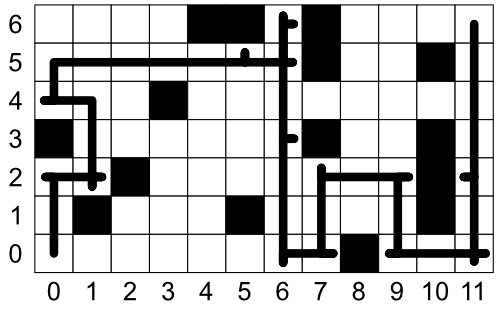

### Rešitev

Tipična študentska rešitev je bila takšna (morda s kakšno vrstico več, a osnovna ideja je enaka).

In [3]:
def sesalec(pot, sirina, visina, ovire_x, ovire_y):
    # Pripravimo slovar, katerega ključi so ovire, 
    # vrednosti pa število zadetkov te ovire
    ovire = {}
    for ox, oy in zip(ovire_x, ovire_y):
        ovire[(ox, oy)] = 0
        
    x = y = 0
    smeri = {"<": (-1, 0), ">": (1, 0), "v": (0, -1), "^": (0, 1)}
    for smer in pot:
        # Izračunamo ciljne koordinate
        dx, dy = smeri[smer]
        nx, ny = x + dx, y + dy  

        # Če je tam ovira, povečajmo število zadetkov
        # Če je zadeta trikrat, jo odstranimo
        if (nx, ny) in ovire:
            ovire[(nx, ny)] += 1
            if ovire[(nx, ny)] == 3:
                del ovire[(nx, ny)]

        # Če je polje znotraj sobe in na njem ni ovire, se premaknemo
        if 0 <= nx < sirina and 0 <= ny < visina and (nx, ny) not in ovire:
            x, y = nx, ny
    return x, y

Končna različica moje rešitve je podobna, le ovir nisem odstranjeval iz slovarja, pač pa preverjam, ali velja `zadetki.get((nx, ny), 3) >= 3`. To bo res, če je ovira že zadeta (vsaj) trikrat ali pa ovire ni - in `get` kot privzeto vrednost vrne, kar podam kot drugi argument, torej `3`.

In [5]:
def sesalec(pot, sirina, visina, ovire_x, ovire_y):
    # Pripravimo slovar, katerega ključi so ovire, 
    # vrednosti pa število zadetkov te ovire
    zadetki = {}
    for ox, oy in zip(ovire_x, ovire_y):
        zadetki[(ox, oy)] = 0
        
    x = y = 0
    smeri = {"<": (-1, 0), ">": (1, 0), "v": (0, -1), "^": (0, 1)}
    for smer in pot:
        # Izračunamo ciljne koordinate
        dx, dy = smeri[smer]
        nx, ny = x + dx, y + dy

        # Če je tam ovira, zabeležimo, da smo jo zadeli
        if (nx, ny) in zadetki:
            zadetki[(nx, ny)] += 1

        # Na polje gremo, je v sobi in tam ni ovire ali pa je bila zadeta trikrat
        if 0 <= nx < sirina and 0 <= ny < visina and zadetki.get((nx, ny), 3) >= 3:
            x, y = nx, ny
    return x, y